In [1]:
import sys
from pathlib import Path

# Add the path to the utils folder to sys.path
utils_path = Path('/hpc/home/a1/WildfireProject/uavsar-fire-detect-main/uavsar-main/python').resolve()
sys.path.append(str(utils_path))

import numpy as np
import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.plot import show

from rio_utils import (reproject_arr_to_match_profile)
from shapely.geometry import Polygon
from shapely.geometry import Point
from PIL import Image
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from matplotlib.colors import ListedColormap

In [20]:
# === Load ground truth and prediction images ===
gt_img = Image.open("/hpc/home/a1/FishLakeFireData/Shapefile/FishLakeFirePerimeter.png").convert('L')
pred_img = Image.open('/hpc/home/a1/FishLakeFireData/PossibleFirePolygons/KMeans/Cropped/Possible_Fire_Polygons_Superpixel_scale1_sigma08_minsize100_prepost.png').convert('L')
# === Resize prediction to match ground truth ===
pred_img_resized = pred_img.resize(gt_img.size, Image.NEAREST)

# Convert to numpy arrays
gt_array = np.array(gt_img)
pred_array = np.array(pred_img_resized)

# === Convert to binary masks (0 = unburned, 1 = burned) ===
gt_mask = (gt_array > 128).astype(np.uint8)
pred_mask = (pred_array > 128).astype(np.uint8)

# === Flatten for confusion matrix ===
y_true = gt_mask.flatten()
y_pred = pred_mask.flatten()

# === Compute confusion matrix (counts and percentages) ===
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
cm_percent = cm / cm.sum() * 100
labels = ['Burned (Black)', 'Unburned (Green)']

# === Compute accuracy and other metrics ===
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

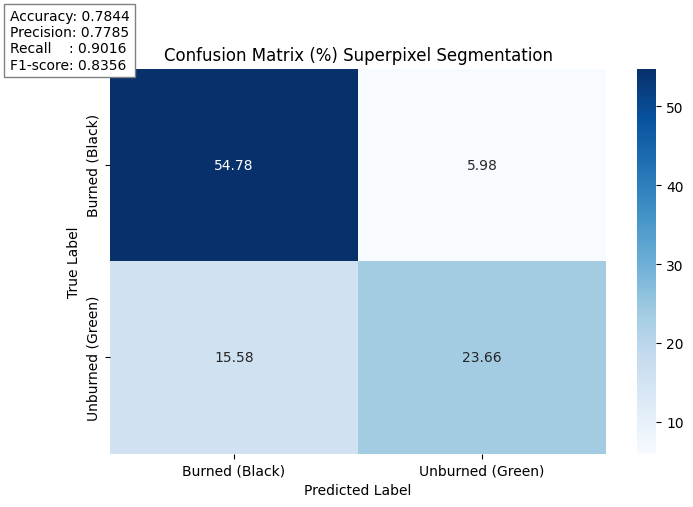

In [21]:
plt.figure(figsize=(8, 5))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (%) Superpixel Segmentation')

# === Add metrics as text below or beside the plot ===
metrics_text = (
    f"Accuracy: {accuracy:.4f}\n"
    f"Precision: {precision:.4f}\n"
    f"Recall    : {recall:.4f}\n"
    f"F1-score: {f1:.4f}"
)

# Add metrics text onto the figure (adjust x/y for position)
plt.gcf().text(0, .88, metrics_text, fontsize=10, 
               bbox=dict(facecolor='white', alpha=1, edgecolor='gray'))

plt.savefig("/hpc/home/a1/FishLakeFireData/ConfusionMatrices/KMeans/Possible_Fire_Polygons_Superpixel_scale1_sigma08_minsize50_prepost.png")
plt.show()